# Henry's Tutorial for TOAST

Date: 01 September 2026

---

This is a basic introduction to using TOAST. This tutorial will walk through the pipeline of making your first Ground Based Telescope TOD simulation. Part 2 of this tutorial will cover a basic pipeline of simulated TOD to maps. 

# Basics of TOAST

In [76]:
# Optionally change logging level
import os
os.environ["TOAST_LOGLEVEL"] = "INFO"
# This is needed before importing toast, and should
# match the value passed to the '-t' option of %toast
os.environ["OMP_NUM_THREADS"] = "8"

# TOAST interactive startup
import toast.interactive
%reload_ext toast.interactive

In [77]:
%toast -p 1 -t 8 -a

TOAST INFO: Using 1 processes with 8 threads each.


In [78]:
import numpy as np
import astropy.units as u
from astropy.table import QTable
import pandas as pd
import os

import toast
from toast.tests import helpers
import inspect
from plotting_utils import *
import healpy as hp

out_dir = 'out_sim_ground/custom_map'

In [79]:
# MPI communicator
world, procs, rank = toast.mpi.get_world()
comm = helpers.create_comm(world, single_group=True)

print(world, procs, rank)

<mpi4py.MPI.Intracomm object at 0x7f5fa036d830> 1 0


TOAST is built using an object-oriented approach to data management. The top level container is a `Data` object. Each `Data` object is made up of a list of `Observations`, which themselves contain information for a given `Telescope`. 

More on these objects will be introduced later, but for now, we need to define our telescope.

## Making a Telescope

The `Telescope` Object requires two vital pieces of information. 
- A telescope `Site`
- A `FocalPlane`

Let's define our telescope site:

TOAST has two built-in site classes (`GroundSite` and `SpaceSite`) built on the base class `Site`.

`GroundSite` defines a ground based site and requires a <span style="color:lightgreen">name, lat, long, alt</span>. Additionally, it can take in <span style="color:lightgreen">weather</span> data.

`SpaceSite` represents a telescope site with no atmosphere. It requires only a _name_ to define.

In [80]:

site = toast.instrument.GroundSite("atacama", "-22:57:30", "-67:47:10", 5200.0 * u.meter)

spacesite = toast.instrument.SpaceSite("HNSpaceTelescope")

Now we can define our `FocalPlane` object.

TOAST has multiple methods for creating focal plane models of varying complexity.

`toast.instrument_sim` has three functions for creating simulated focal planes:
- `fake_hexagon_focalplane` - creates a simple hexagon-packed focal plane. Not the most realistic but a simple implementation.
- `fake_rhombihex_focalplane` - creates a simple focal plane built up of 3 rhombi. Not the most realistic but a simple implementation. The number of pixels per rhombus (<span style="color:lightgreen">n_pix_rhombus</span>) must be a square number.
- `fake_boresight_focalplane` - Create a focalplane with all detectors at the boresight for testing.


In [81]:
from toast.instrument_sim import (
    fake_rhombihex_focalplane,
    fake_boresight_focalplane,
    fake_hexagon_focalplane,
    plot_focalplane
)

In [82]:
fp_fwhm = 30.0 * u.arcmin

focalplane = fake_rhombihex_focalplane(
    n_pix_rhombus=25,# Number of pixels per rhombus must be a perfect square
    width=8.0 * u.degree, # field of view of the focal plane
    gap=0 * u.radian,
    sample_rate=10.0 * u.Hz,
    epsilon=0.0,
    fwhm=fp_fwhm, # Beam size
    bandcenter=150 * u.GHz,
    bandwidth=20 * u.GHz,
    psd_net=300.0 * u.uK * np.sqrt(1 * u.second),
    psd_fmin=1.0e-5 * u.Hz,
    psd_alpha=1.0,
    psd_fknee=0.05 * u.Hz,
    fwhm_sigma=0.0 * u.arcmin,
    bandcenter_sigma=0 * u.GHz,
    bandwidth_sigma=0 * u.GHz,
    random_seed=123456,
)
fov = focalplane.field_of_view

<span style="color:red">Note:</span> This `FocalPlane` only considers one frequency band. For a dichroic/multichroic focal plane, it currently seems like you need to model another `FocalPlane` object.

We can plot that `FocalPlane` using:

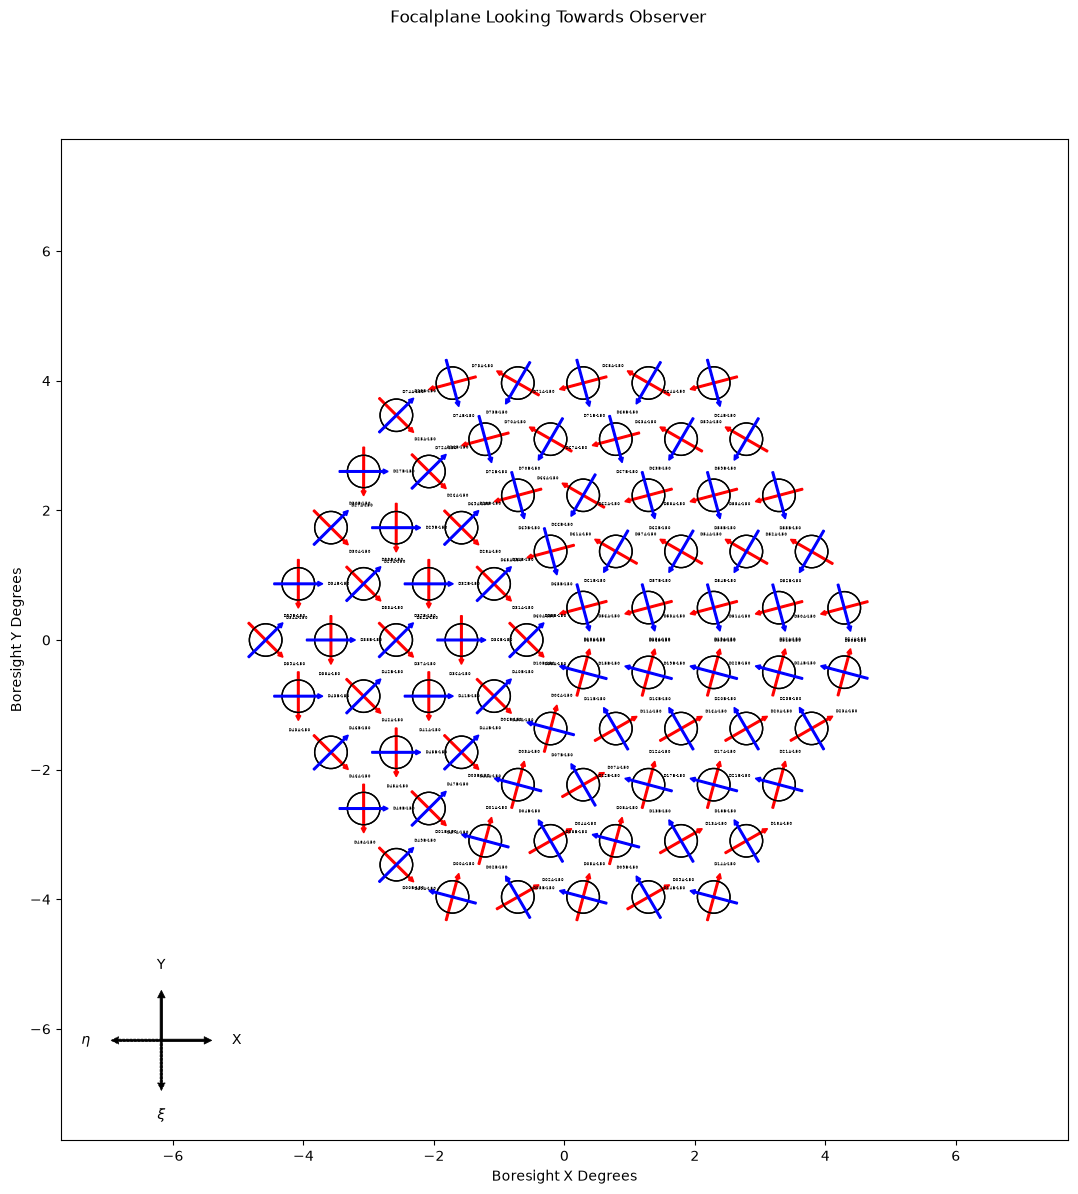

In [83]:
# We will define colors for our two polarization angles
detpolcol = {
    x: "red" if "A" in x else "blue" for x in focalplane.detectors
}

# Plot the focal plane
_ = plot_focalplane(
    focalplane=focalplane,
    width=1.3 * fov,
    height=1.3 * fov,
    show_labels=True,
    pol_color=detpolcol
)

Now that we have defined both our `FocalPlane` and out `Site`. We can make our `Telescope` object.

In [84]:
telescope = toast.Telescope(name="HenryTelescope", focalplane = focalplane, site = site)

## Exploring our Telescope

Now that we have made a `Telescope`. How do we access the information is stored in the object?

In [85]:
print(type(focalplane))
print(focalplane)

<class 'toast.instrument.Focalplane'>
<Focalplane: 150 detectors, sample_rate = 10.0 Hz, FOV = 9.9 deg, detectors = [D00A-150 .. D74B-150]>


In [86]:
print(focalplane.detectors)
print(focalplane.n_detectors)

[np.str_('D00A-150'), np.str_('D00B-150'), np.str_('D01A-150'), np.str_('D01B-150'), np.str_('D02A-150'), np.str_('D02B-150'), np.str_('D03A-150'), np.str_('D03B-150'), np.str_('D04A-150'), np.str_('D04B-150'), np.str_('D05A-150'), np.str_('D05B-150'), np.str_('D06A-150'), np.str_('D06B-150'), np.str_('D07A-150'), np.str_('D07B-150'), np.str_('D08A-150'), np.str_('D08B-150'), np.str_('D09A-150'), np.str_('D09B-150'), np.str_('D10A-150'), np.str_('D10B-150'), np.str_('D11A-150'), np.str_('D11B-150'), np.str_('D12A-150'), np.str_('D12B-150'), np.str_('D13A-150'), np.str_('D13B-150'), np.str_('D14A-150'), np.str_('D14B-150'), np.str_('D15A-150'), np.str_('D15B-150'), np.str_('D16A-150'), np.str_('D16B-150'), np.str_('D17A-150'), np.str_('D17B-150'), np.str_('D18A-150'), np.str_('D18B-150'), np.str_('D19A-150'), np.str_('D19B-150'), np.str_('D20A-150'), np.str_('D20B-150'), np.str_('D21A-150'), np.str_('D21B-150'), np.str_('D22A-150'), np.str_('D22B-150'), np.str_('D23A-150'), np.str_('D23

Detector information is stored in the `FocalPlane.detector_data` attribute. This is an `astropy.QTable` object and can be viewed using the astropy `show_in_notebook` method.

In [87]:
print(focalplane.properties)
print(type(focalplane.detector_data))
focalplane.detector_data.show_in_notebook()

['name', 'quat', 'pol_leakage', 'psi_pol', 'gamma', 'fwhm', 'psd_fmin', 'psd_fknee', 'psd_alpha', 'psd_net', 'bandcenter', 'bandwidth', 'pixel', 'uid', 'pol_angle', 'pol_efficiency']
<class 'astropy.table.table.QTable'>


DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

Another useful focal plane function is the `detector_groups` method. 

This selects a column of the `detector_data` and returns a dictionary where the keys are the unique values in that column, and the values are the corresponding detector names.

In [88]:
# For example, we can split our detectors by polarization
psi_pol_dict = focalplane.detector_groups(column='psi_pol')
print(f"This dictionary has two keys, one for each polarization state {psi_pol_dict.keys()}")
psi_pol_list = list(psi_pol_dict.items())
print(f"The detectors corresponding to polarization state: {psi_pol_list[0][0]} are\n{psi_pol_list[0][1]}")

This dictionary has two keys, one for each polarization state dict_keys([<Quantity 0. rad>, <Quantity 1.57079633 rad>])
The detectors corresponding to polarization state: 0.0 rad are
[np.str_('D00A-150'), np.str_('D01A-150'), np.str_('D02A-150'), np.str_('D03A-150'), np.str_('D04A-150'), np.str_('D05A-150'), np.str_('D06A-150'), np.str_('D07A-150'), np.str_('D08A-150'), np.str_('D09A-150'), np.str_('D10A-150'), np.str_('D11A-150'), np.str_('D12A-150'), np.str_('D13A-150'), np.str_('D14A-150'), np.str_('D15A-150'), np.str_('D16A-150'), np.str_('D17A-150'), np.str_('D18A-150'), np.str_('D19A-150'), np.str_('D20A-150'), np.str_('D21A-150'), np.str_('D22A-150'), np.str_('D23A-150'), np.str_('D24A-150'), np.str_('D25A-150'), np.str_('D26A-150'), np.str_('D27A-150'), np.str_('D28A-150'), np.str_('D29A-150'), np.str_('D30A-150'), np.str_('D31A-150'), np.str_('D32A-150'), np.str_('D33A-150'), np.str_('D34A-150'), np.str_('D35A-150'), np.str_('D36A-150'), np.str_('D37A-150'), np.str_('D38A-150'

# Observation Data

In TOAST the data is treated as an object upon which operations act. `Operators`, typically found in the `toast.ops` module, define some set of operations to perform on the data. This can range from applying pointing to saving objects to file. The standard syntax for applying an operation is:
```python
operation = toast.ops.<OperatorName>(*args, **kwargs)
operation.apply(data)
```

An example observation simulation might be composed of the following steps:
1. Apply a schedule to the data - data indicating telescope motion etc.
2. Apply detector pointing to the data
3. Apply a scan of a simulated CMB to the data
4. Apply noise to the data
5. Apply Scan Synchronous Signals like ground pickup
6. Apply a simulated atmosphere

Let's see this in action:

In [89]:
# Start with an empty data container
data = toast.Data(comm)

## Observing Schedule

Schedules can get really complicated, we will stick with a simple one for the purposes of this tutorial.

Schedules include reference to sky patches. Patches use the `Patch` class.

Somewhat annoyingly, the `schedule_sim_ground.run_scheduler` option for patch takes in a unique (comma-delimited) string which is parsed using the `schedule_sim_ground.parse_patches` function.

Generally that string contains the following information:

[0]: Patch name
[1]: Patch weight (priority), or a special tag to define the type of patch (e.g. HORIZONTAL, SIDEREAL)

If there are 3 remaining values in the string, they define a patch with a center of `lon, lat = parts[2], parts[3]` and a width of `width = parts[4]` (all in degrees).

If there are 4 remaining values in the string, they define a patch with bounds given by `lon_min, lat_max, lon_max, lat_min = parts[2], parts[3], parts[4], parts[5]` (all in degrees).



In [90]:
# Define the output file for our schedule 
sch_file = os.path.join(out_dir, "test_schedule.txt")

ra = 0 * u.deg
dec = -60 * u.deg
width = 10 * u.deg
# This functions takes in the various command line arguments to design a 
# schedule that meets the needs of the observation
# It then outputs the designed schedule as a txt file
toast.schedule_sim_ground.run_scheduler(
    opts=[
        "--site-name", telescope.site.name,
        "--telescope", telescope.name,
        "--site-lon", "{}".format(telescope.site.earthloc.lon.to_value(u.degree)),
        "--site-lat", "{}".format(telescope.site.earthloc.lat.to_value(u.degree)),
        "--site-alt", "{}".format(telescope.site.earthloc.height.to_value(u.meter)),
        "--patch", "test,1,{},{},{}".format(ra.value, dec.value, width.value),
        "--start", "2026-09-01 00:00:00",
        "--stop", "2026-09-02 12:00:00",
        "--out", sch_file,
        "--equalize-time",
        "--patch-coord", "C", # C for Equatorial (RA-Dec), E for Ecliptic (Lon Lat), and G for Galactic
        "--el-min", "20",
        "--el-max", "50",
        "--sun-el-max", "90",
        "--sun-avoidance-angle", "30",
        "--moon-avoidance-angle", "0",
        "--ces-max-time", "36000",
        "--fp-radius", "0",
        # "--boresight-angle-step", "180",
        # "--boresight-angle-time", "1440",
        "--time-step-s", "600",
        "--lock-az-range",
        "--elevations", "25, 30, 35, 40, 45",
    ]
)

TOAST INFO: Adding patch "test"
TOAST INFO: Center-and-width format
TOAST INFO: Creating 'out_sim_ground/custom_map'


Now we create a schedule object, and apply the schedule file we just made to that object.

In [91]:
schedule = toast.schedule.GroundSchedule()
schedule.read(sch_file)

TOAST INFO: Loading schedule from out_sim_ground/custom_map/test_schedule.txt
TOAST INFO: Loaded 8 scans from out_sim_ground/custom_map/test_schedule.txt totaling 11.8 hours.


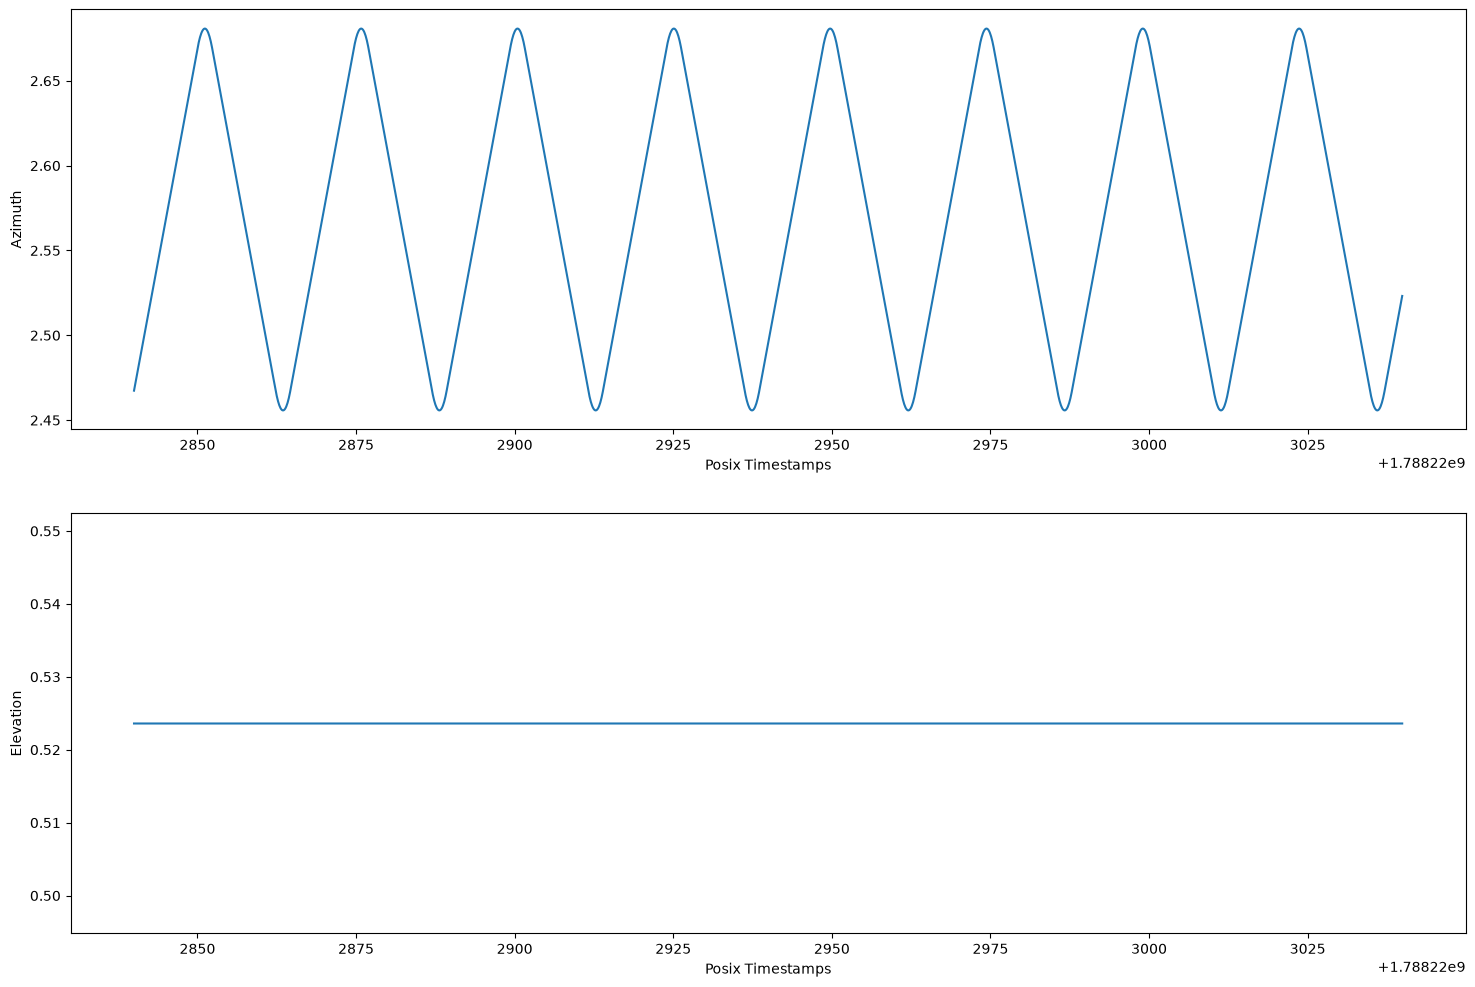

In [92]:
# Populate observations according to the schedule and telescope.
sim_ground = toast.ops.SimGround(
    telescope=telescope,
    weather="atacama",
    detset_key="pixel",
    schedule=schedule,
    median_weather=True, # no longer random weather, but less chance of an outlier
)

sim_ground.apply(data)

if rank == 0:
    plot_scanning(data.obs[0], s_start=0, s_end=2000)

## Inspecting the Observation

Now the data includes information about how the telescope will move.

In [93]:
print(data.obs)

[<Observation
  name = 'test-0-0'
  uid = '594457246'  group has 1 processes
  telescope = <Telescope 'HenryTelescope': uid = 2011423616, site = <GroundSite 'atacama' : uid = 39949029, lon = -67.7861111111111 deg, lat = -22.958333333333332 deg, alt = 5199.999999999725 m, weather = <SimWeather : 'atacama', year = 2026, month = 7, hour = 1, site UID = 39949029, realization = 0, median = True)>, focalplane = <Focalplane: 150 detectors, sample_rate = 10.0 Hz, FOV = 9.9 deg, detectors = [D00A-150 .. D74B-150]>>
  session = <Session 'test-0-0': uid = 1371551243, start = 2026-09-01 00:34:00+00:00, end = 2026-09-01 01:53:59.900000+00:00>
  scan_el = 30.0 deg
  scan_min_el = 0.5235987755982988 rad
  scan_max_el = 0.5235987755982988 rad
  scan_min_az = 2.4557364353139364 rad
  scan_max_az = 2.6807675502494854 rad
  48000 total samples (48000 local)
  shared:  <SharedDataManager
    times (column): shape=(np.int64(48000),), dtype=float64
    position (column): shape=(np.int64(48000), 3), dtype=fl

We can see that an `Observation` object was added to the data.

Let's inspect what is currently in that `Observation`.

Note: data stored in an observation can be split across MPI processes.

In [94]:
ob = data.obs[0]
# If we want to explore the detector data that is included
print(ob.detdata)
print(type(ob.detdata))

<DetDataManager 150 local detectors, 48000 samples
    signal: shape=(150, np.int64(48000)), dtype=float64, units='K'
    flags: shape=(150, np.int64(48000)), dtype=uint8, units=''>
<class 'toast.observation_data.DetDataManager'>


We can take a peak at some of the detector data

In [95]:
def get_det_slice(obs, det, slc, signal="signal"):
    return obs.detdata[signal][det, slc]

In [96]:
slc = slice(0,10,1)
det = "D00A-150"
det_slice = get_det_slice(ob, det, slc)
print(f"{slc} of detector {det}: {det_slice}")

slice(0, 10, 1) of detector D00A-150: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


As we can see, and as we expect the data is all empty.

## Detector Pointing

There are 3 types of operators that define the detector pointing:
1. The first is the geometric offset from the boresight coordinate frame to the detector coordinate frame. In the simplest case this is just a quaternion for each detector (stored in the focalplane table). 
2. Once the geometric detector pointing is computed, the pixelization on the sky is specified by a separate operator. 
3. Finally, the response of the detector to incoming Stokes parameters is given by another operator.

We will start by applying the geometric detector pointing from the boresight to the detector frame. We will define these for both horizontal and equatorial coordinates as the detector pointing in horizontal coordinates will be useful for atmosphere simulation later on.

In [97]:
det_point_azel = toast.ops.PointingDetectorSimple(
    boresight=defaults.boresight_azel,
    quats="quats_azel"
)

print(det_point_azel)

det_point_radec = toast.ops.PointingDetectorSimple(
    boresight=defaults.boresight_radec,
    quats="quats_radec"
)

<PointingDetectorSimple
  API = 0 # Internal interface version for this operator
  boresight = boresight_azel # Observation shared key for boresight
  coord_in = None # The input boresight coordinate system ('C', 'E', 'G')
  coord_out = None # The output coordinate system ('C', 'E', 'G')
  det_mask = 1 # Bit mask value for per-detector flagging
  enabled = True # If True, this class instance is marked as enabled
  hwp_angle = hwp_angle # Observation shared key for HWP angle
  hwp_angle_offset = 0.0 deg # HWP angle offset to apply when constructing deflection
  hwp_deflection_radius = None # If non-zero, nominal detector pointing will be deflected in a circular pattern according to HWP phase.
  kernel_implementation = 0 # Which kernel implementation to use (DEFAULT, COMPILED, NUMPY, JAX).
  name = PointingDetectorSimple # The 'name' of this class instance
  quats = quats_azel # Observation detdata key for output quaternions
  shared_flag_mask = 1 # Bit mask value for optional flagging
 

Even though the inputs (and attributes) of the `PointingDetectorSimple` are strings, these strings indicate how the detector pointing is adjust from the boresight frame.

In [98]:
# Pixelization.  Choose a coarse pixelization for this exercise since there is
# a small patch and only a few detectors.

nside = 256
pixels_radec = toast.ops.PixelsHealpix(
    nside=nside,
    nest=True,
    detector_pointing=det_point_radec,
)




In [99]:
# Stokes weights.  This just uses focalplane table properties to treat each detector
# as a linear polarizer with possibly some cross-polar response.

weights_azel = toast.ops.StokesWeights(
    mode="IQU",
    detector_pointing=det_point_azel,
)

weights_radec = toast.ops.StokesWeights(
    mode="IQU",
    detector_pointing=det_point_radec,
)

pixels_radec.apply(data)
weights_radec.apply(data)

### Pixel Distribution

When working with sky data for both simulations and mapmaking, each process only stores pixels which are "hit" by the local detectors on that process.

Computing this "pixel distribution" requires passing through the pointing. Normally this is done without saving the detector pointing (for memory considerations). In this notebook, we just compute the full detector pointing once at the beginning and save it.

In [100]:
pix_dist = toast.ops.BuildPixelDistribution(
    pixel_dist="pixel_dist",
    pixel_pointing=pixels_radec,
)
pix_dist.apply(data)

## Synthetic Sky

In order to have some kind of sky signal in our data, we generate a fake sky and scan that into timestreams.

Now that we have simulated the sky, we can simulate a scan of this map.

[-0.00803681 -0.00920884 -0.009827   ... -0.01556242 -0.0108094
 -0.01273313]
TOAST INFO: Pixel data in /shared_home/henachman/SO_PointingReqs/sim_sky_maps/maps/map_with_3FWHM_source.fits does not have TUNIT1 key.  Assuming 'K'.


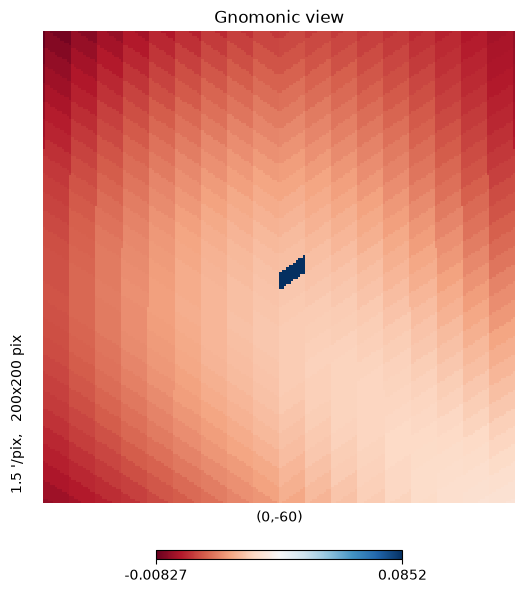

In [101]:
# Scan the map
input_map_file = "/shared_home/henachman/SO_PointingReqs/sim_sky_maps/maps/map_with_3FWHM_source.fits"
# input_map_file = "/shared_home/henachman/SO_PointingReqs/toast_tutorial/out_sim_ground/fake_sky.fits"

input_map = hp.read_map(input_map_file, nest=True)
print(input_map)

hp.gnomview(input_map, rot=[ra.value, dec.value], xsize=200, nest=True, cmap='RdBu')

scan_map = toast.ops.ScanHealpixMap(
    file=input_map_file,
    pixel_pointing=pixels_radec,
    stokes_weights=weights_radec,
)
scan_map.apply(data)

## Checkpoint 2

Let's reinspect some of the detector data now that we have performed a 'scan'.

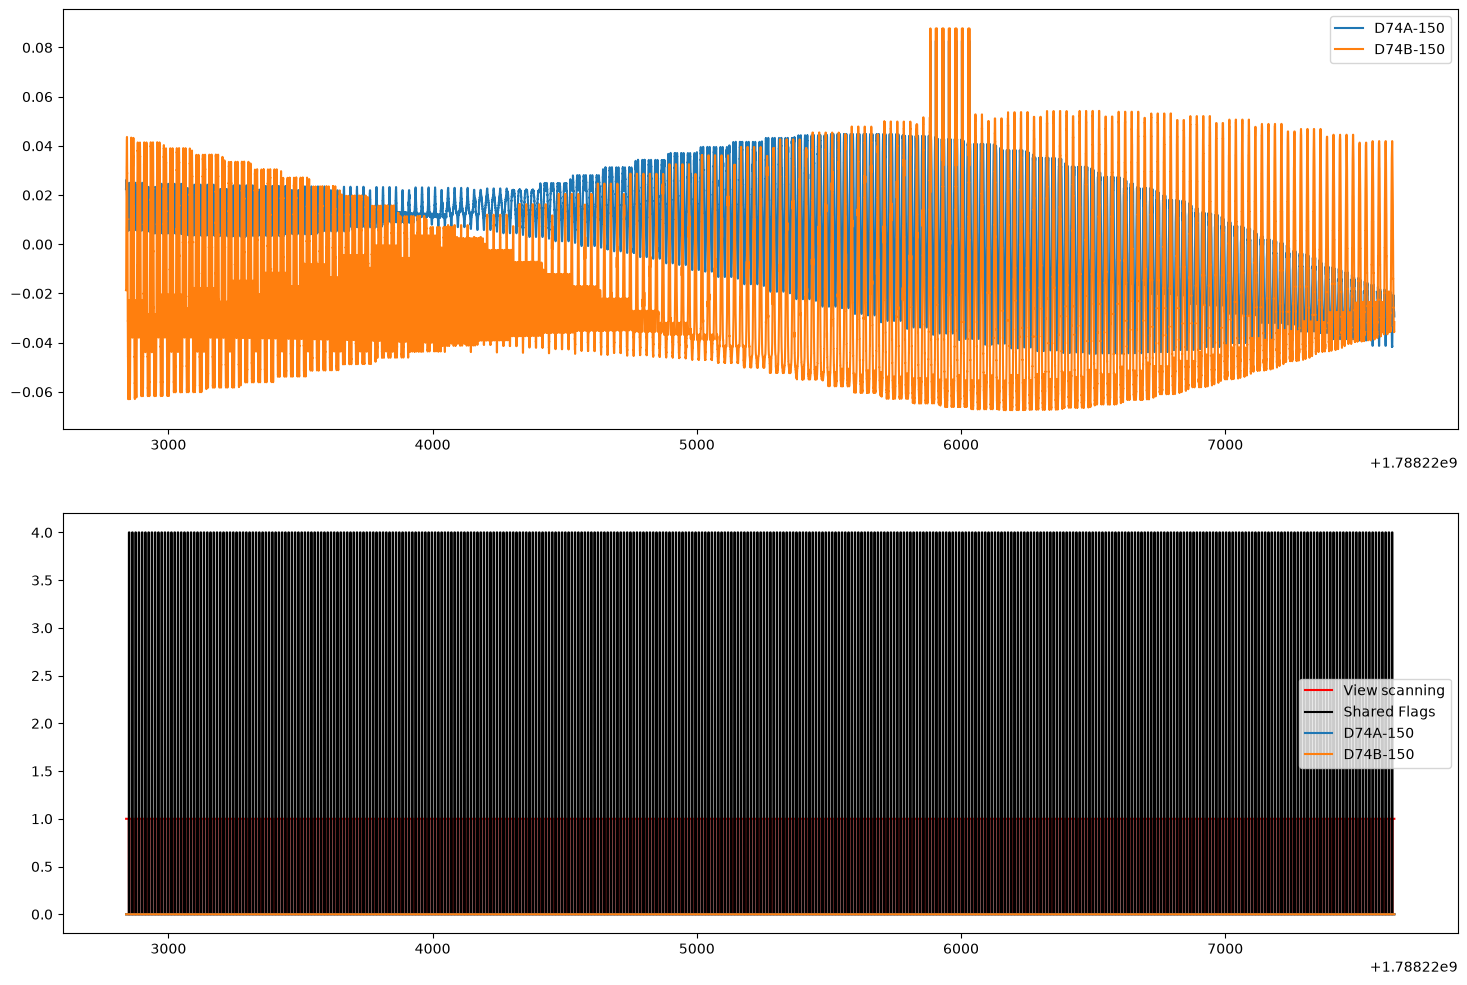

In [102]:
ob = data.obs[0]
if rank == 0:
    plot_dets(ob, d_start=148, d_end=None, s_start=0, s_end=80000, view="scanning")

## Save basic data

Save the data as an hdf5 file. And also save a corresponding area fits file.

In [103]:
print(out_dir)
save_data = toast.ops.SaveHDF5()
save_data.apply(data)
print(save_data)

out_sim_ground/custom_map


TOAST INFO: Wrote toast_out_hdf5/test-0-0.h5


A coordinate or time-related calculation might be compromised or fail because the dates are not covered by the available IERS file.  See the "IERS data access" section of the astropy documentation for additional information on working offline. [astropy.utils.iers.iers]


ValueError: interpolating from IERS_Auto using predictive values that are more
than 30.0 days old.

Normally you should not see this error because this class
automatically downloads the latest IERS-A table.  Perhaps you are
offline?  If you understand what you are doing then this error can be
suppressed by setting the auto_max_age configuration variable to
``None``:

  from astropy.utils.iers import conf
  conf.auto_max_age = None


Wrote geometry: shape=(np.int64(716), np.int64(716)), footprint RA=[278.06,301.94]deg, Dec=[-71.94,-48.06]deg, res=2.0 arcmin -> out_sim_ground/custom_map/area.fits


## Instrumental Noise
We create a trivial noise model using nominal parameters from the focalplane table and then use this noise model to simulate timestreams.

In [104]:
nominal_noise = toast.ops.DefaultNoiseModel()
nominal_noise.apply(data)

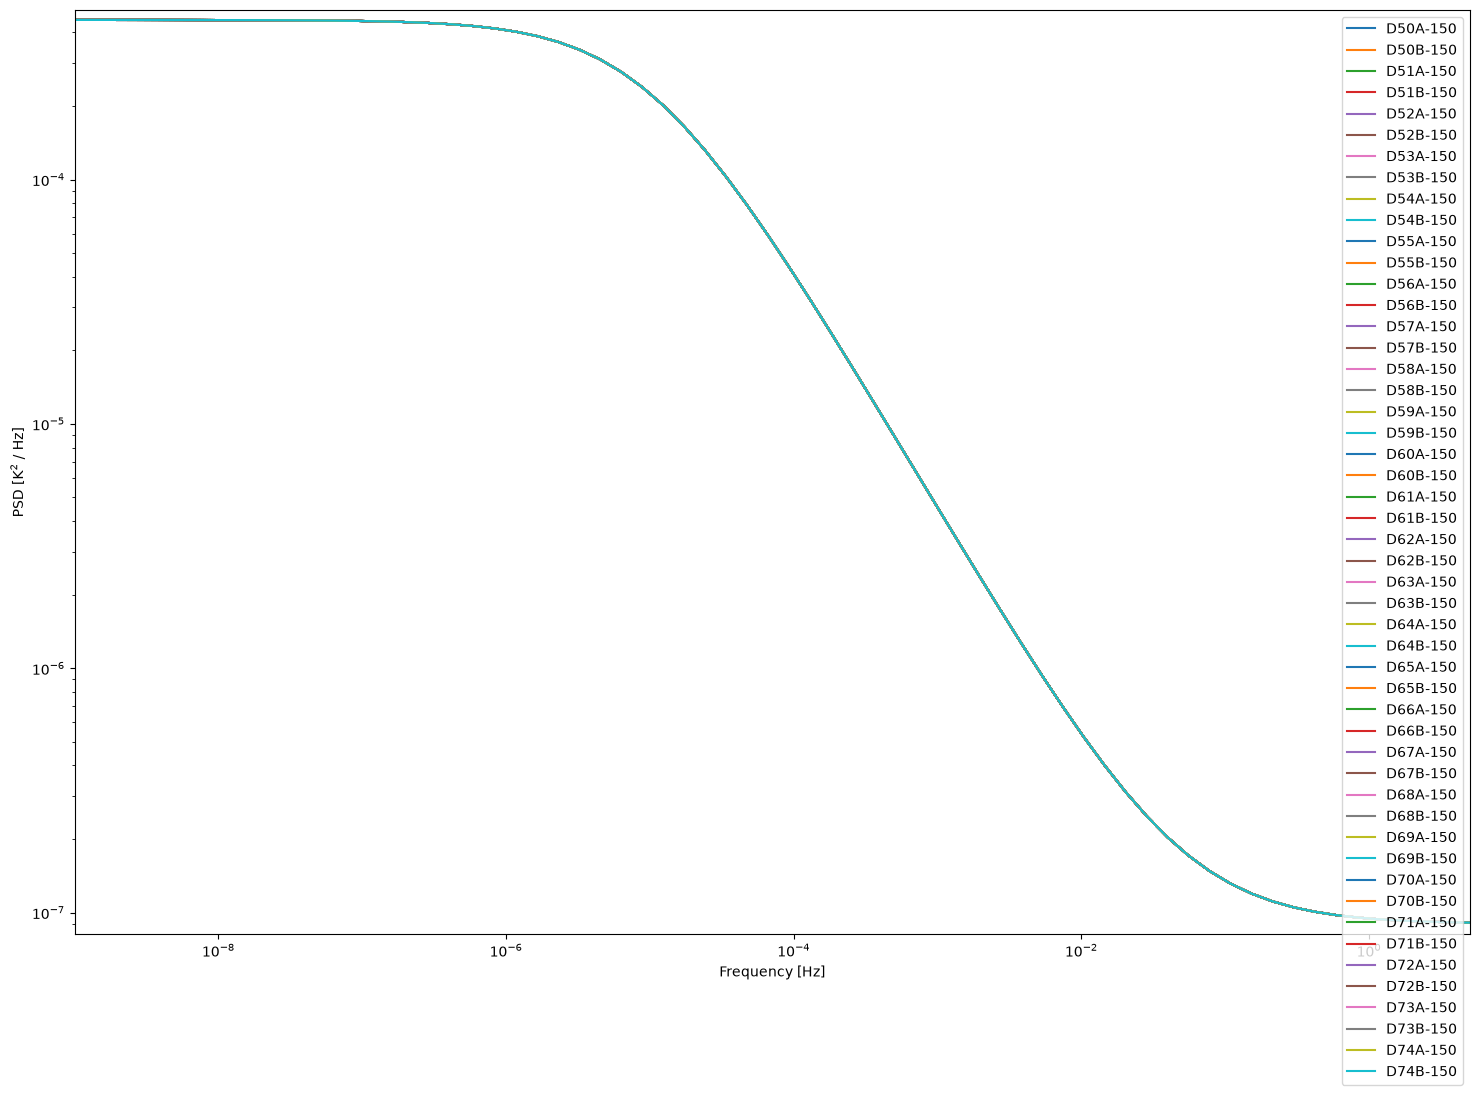

In [105]:
# Plot this nominal noise model for the last few detectors
if rank == 0:
    plot_noise_model(
        data.obs[0][nominal_noise.noise_model],
        model_fit=None,
        d_start=100,
        d_end=None
    )

In [106]:
sim_noise = toast.ops.SimNoise(
    noise_model=nominal_noise.noise_model,
)
sim_noise.apply(data)

## Scan Synchronous Signal - Ground Pickup

The ground and environment around the telescope may produce different loading as a function of azimuth as the telescope scans. This kind of signal is one of several possible "scan synchronous signals".

In [107]:
ground_pickup = toast.ops.SimScanSynchronousSignal(
    detector_pointing=det_point_azel,
    scale=0.001 * u.K,
    stokes_weights=weights_azel,
)
ground_pickup.apply(data)

## Simulated Atmosphere

Now we will simulate a 3D atmospheric slab moving in front of the telescope and integrate each detector along the line of site and over its bandpass. In order to do this, we have to define an operator which knows how to compute detector pointing in Az/El coordinates. This just uses the boresight pointing and the detector quaternion rotations from the boresight to compute detector pointing.

In [108]:
sim_atm = toast.ops.SimAtmosphere(
    detector_pointing=det_point_azel,
    add_loading=True,
    lmin_center=0.001 * u.m,
    lmin_sigma=0.0001 * u.m,
    lmax_center=1.0 * u.m,
    lmax_sigma=0.1 * u.m,
    xstep=20 * u.m,
    ystep=20 * u.m,
    zstep=20 * u.m,
    zmax=200 * u.m,
    gain=4e-5,
    wind_dist=1000 * u.m,
)
sim_atm.apply(data)

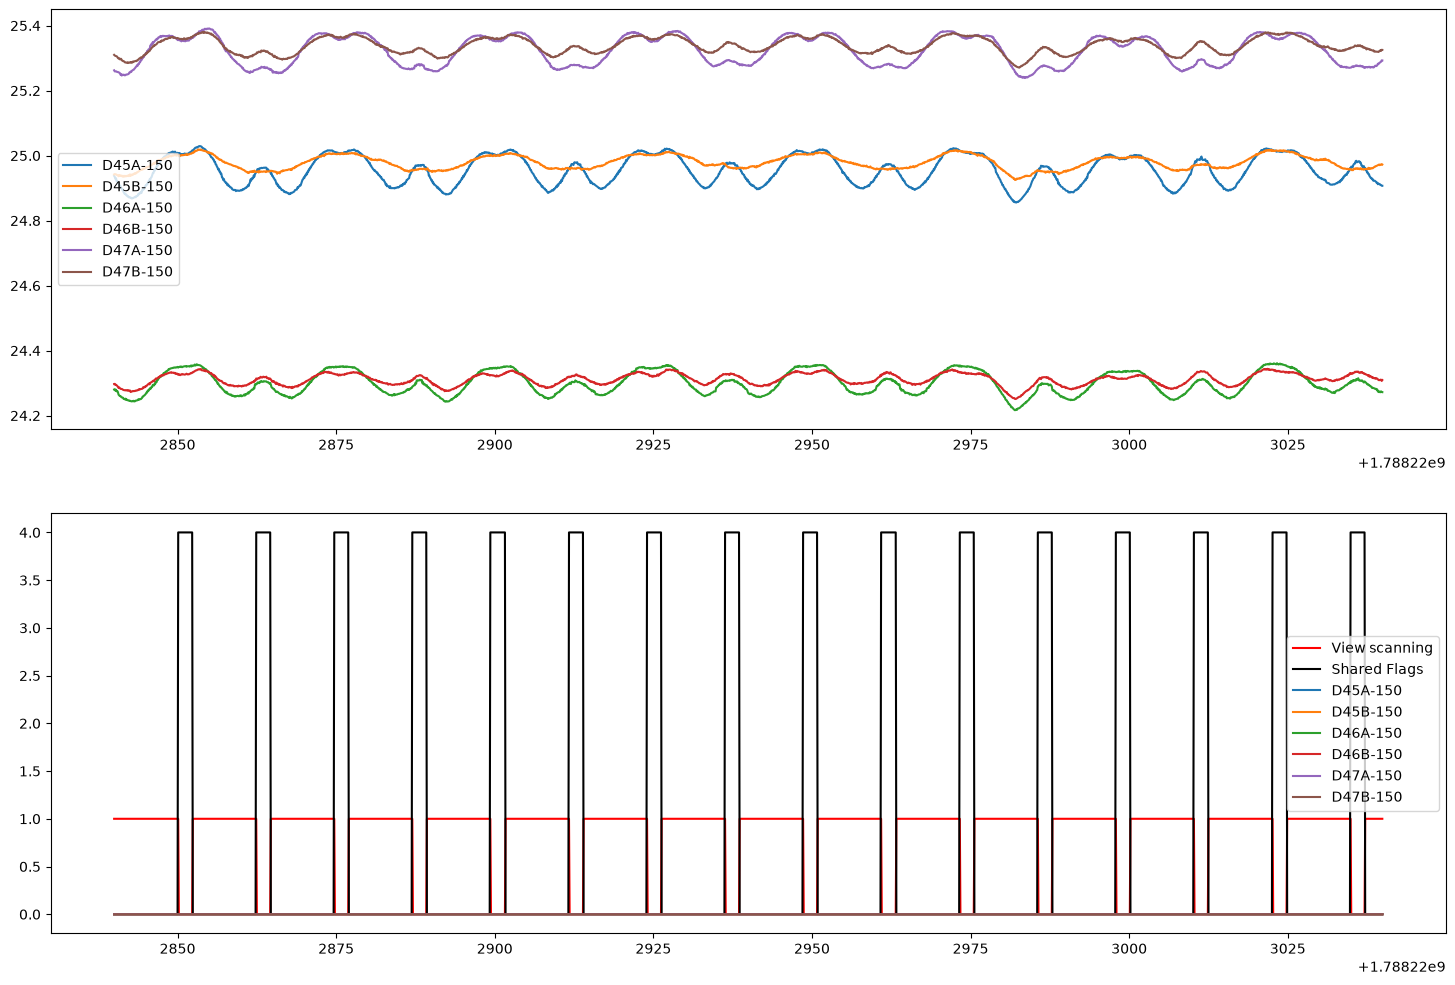

In [109]:
# Plot the last few normal detectors
if rank == 0:
    plot_dets(data.obs[0], d_start=90, d_end=96, s_start=0, s_end=2000, view="scanning")

In [110]:
print(sim_atm.detector_pointing)

<PointingDetectorSimple
  API = 0 # Internal interface version for this operator
  boresight = boresight_azel # Observation shared key for boresight
  coord_in = None # The input boresight coordinate system ('C', 'E', 'G')
  coord_out = None # The output coordinate system ('C', 'E', 'G')
  det_mask = 1 # Bit mask value for per-detector flagging
  enabled = True # If True, this class instance is marked as enabled
  hwp_angle = hwp_angle # Observation shared key for HWP angle
  hwp_angle_offset = 0.0 deg # HWP angle offset to apply when constructing deflection
  hwp_deflection_radius = None # If non-zero, nominal detector pointing will be deflected in a circular pattern according to HWP phase.
  kernel_implementation = 0 # Which kernel implementation to use (DEFAULT, COMPILED, NUMPY, JAX).
  name = PointingDetectorSimple # The 'name' of this class instance
  quats = quats_azel # Observation detdata key for output quaternions
  shared_flag_mask = 1 # Bit mask value for optional flagging
 

# Pointing Visualization

In [111]:
from toast.vis import plot_projected_quats

In [112]:
slc = slice(500, 515, 3)

# Boresight quaternion for the slice — use boresight_azel for ground data,
# boresight_radec if you want celestial coordinates
bquat = np.array(ob.shared[defaults.boresight_radec].data[slc, :])

# Detector quaternions for the slice, shape (n_det, n_samp, 4)
dets = ob.local_detectors
print(ob.detdata)
dquat = np.array([ob.detdata["quats_radec"][d][slc, :] for d in dets])
print(dquat)
# Mask out flagged samples
invalid = np.array(ob.shared[defaults.shared_flags][slc])
invalid &= defaults.shared_mask_invalid
valid = np.logical_not(invalid)

plot_projected_quats(
    os.path.join(out_dir, "pointing.png"),
    qbore=bquat,
    qdet=dquat,
    valid=valid,
    scale=1.0,
)

<DetDataManager 150 local detectors, 48000 samples
    signal: shape=(150, np.int64(48000)), dtype=float64, units='K'
    flags: shape=(150, np.int64(48000)), dtype=uint8, units=''
    quats_radec: shape=(150, np.int64(48000), 4), dtype=float64, units=''
    pixels: shape=(150, np.int64(48000)), dtype=int64, units=''
    weights: shape=(150, np.int64(48000), 3), dtype=float64, units=''
    quats_azel: shape=(1, np.int64(48000), 4), dtype=float64, units=''>
[[[ 0.96266271  0.06641867  0.25100433  0.07658916]
  [ 0.96322583  0.06790483  0.24842783  0.07660644]
  [ 0.96378012  0.06939038  0.24584906  0.07662309]
  [ 0.96432557  0.07087531  0.24326804  0.07663909]
  [ 0.96486217  0.0723596   0.2406848   0.07665444]]

 [[ 0.72767042 -0.63374023  0.23164358 -0.12333015]
  [ 0.72911948 -0.63308755  0.22983394 -0.12149607]
  [ 0.73056187 -0.63242905  0.22802224 -0.11966083]
  [ 0.73199756 -0.63176474  0.2262085  -0.11782446]
  [ 0.73342655 -0.63109462  0.22439273 -0.11598698]]

 [[ 0.96069088 

We have now successfully created a TOAST simulated observation. Before we continue, we will output this observation so that we can import it for later use without rerunning this notebook.

In [113]:
print(ob)

<Observation
  name = 'test-0-0'
  uid = '594457246'  group has 1 processes
  telescope = <Telescope 'HenryTelescope': uid = 2011423616, site = <GroundSite 'atacama' : uid = 39949029, lon = -67.7861111111111 deg, lat = -22.958333333333332 deg, alt = 5199.999999999725 m, weather = <SimWeather : 'atacama', year = 2026, month = 7, hour = 1, site UID = 39949029, realization = 0, median = True)>, focalplane = <Focalplane: 150 detectors, sample_rate = 10.0 Hz, FOV = 9.9 deg, detectors = [D00A-150 .. D74B-150]>>
  session = <Session 'test-0-0': uid = 1371551243, start = 2026-09-01 00:34:00+00:00, end = 2026-09-01 01:53:59.900000+00:00>
  scan_el = 30.0 deg
  scan_min_el = 0.5235987755982988 rad
  scan_max_el = 0.5235987755982988 rad
  scan_min_az = 2.4557364353139364 rad
  scan_max_az = 2.6807675502494854 rad
  noise_model = <AnalyticNoise model with 150 detectors>
  sss_realization = 0
  48000 total samples (48000 local)
  shared:  <SharedDataManager
    times (column): shape=(np.int64(48000

In [114]:
# save_data = toast.ops.SaveHDF5()
# save_data.apply(data)

# Map Making

## Filtering

In [115]:
filter = toast.ops.CommonModeFilter(
    redistribute=False,
    regress=True,
)

filter.apply(data)

## Noise Estimation

The original noise estimate (used above to simulate instrument noise) only captures the nominal readout and detector noise sources. For map making we will treat the timestream as noise-dominated and estimate the noise model directly from the timestream. First, create a raw, binned estimate of the PSD in each detector:

In [116]:
# Estimate noise
estim = toast.ops.NoiseEstim(
    out_model="noise_estimate",
    lagmax=100,
    nbin_psd=32,
    nsum=1,
)
estim.apply(data)

This raw estimate can produce undesired effects if we use it directly in mapmaking. Instead, we first fit an analytic 1/f noise model to these.

In [117]:
# Compute a 1/f fit to this
noise_fitter = toast.ops.FitNoiseModel(
    noise_model=estim.out_model,
    out_model="fit_noise_model",
)
noise_fitter.apply(data)

TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Co

TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Co

/shared_home/software/soconda_builds/soconda_20260813_0.2.5/lib/python3.13/site-packages/toast/ops/noise_model.py:158: OptimizeWarning: Covariance of the parameters could not be estimated
  params, params_cov = curve_fit(


TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Consider changing noise estimation parameters.
TOAST WARNING: Some PSDs have negative values.  Co

In [118]:
# Plot this nominal noise model for the last few detectors
if rank == 0:
    plot_noise_model(
        data.obs[0][estim.out_model],
        model_fit=data.obs[0][noise_fitter.out_model],
        d_start=90,
        d_end=None
    )

## Binning Operator

A central piece of the mapmaking is the "binning" of timestreams into maps. This process accumulates the "noise weighted map" and then multiplies this by the diagonal pixel covariance:

$$
\text{Binned Map} = (P^TN^{-1}P)^{-1}P^TN^{-1}d
$$

You can see from this that in addition to the input timestream data we need the estimated noise model and the pointing matrix.

In [119]:
# Set up binning operator for solving
binner = toast.ops.BinMap(
    pixel_dist=pix_dist.pixel_dist,
    pixel_pointing=pixels_radec,
    stokes_weights=weights_radec,
    noise_model=noise_fitter.out_model,
)

## Template Matrix

The TOAST mapmaker is a "generalized destriper" that solves for "template amplitudes". These templates represent anything in the time ordered data which is not fixed on the sky or simply white noise. For this example, we will use 2 templates. One to model the scan synchronous signal and one to model the 1/f noise (including the atmosphere).

In [120]:
# The Offset template models 1/f noise as a stepwise function, which
# is the same as a "classic" destriper.

tmpl_offset = toast.templates.Offset(
    times=defaults.times,
    noise_model=noise_fitter.out_model,
    step_time=1.0 * u.second,
)

In [121]:
# Build a template matrix with our templates.

tmatrix = toast.ops.TemplateMatrix(
    templates=[tmpl_offset],
)

## Making the Map

Now we are ready to instantiate the mapmaker operator. Note that if we do not specify the template matrix, then this will just produce a binned map.

In [122]:
map_maker = toast.ops.MapMaker(
    name="mapmaker",
    binning=binner,
    template_matrix=tmatrix,
    solve_rcond_threshold=1.0e-1,
    map_rcond_threshold=1.0e-1,
    iter_min=200,
    iter_max=300,
    write_hits=True,
    write_map=True,
    write_binmap=True,
    write_cov=False,
    write_invcov=False,
    write_rcond=True,
    output_dir=out_dir,
    keep_solver_products=True, # We set this to True so we can plot solved template amplitudes later
)
map_maker.apply(data)

TOAST INFO: SolveAmplitudes begin building flags for solver


TOAST INFO: SolveAmplitudes  finished flag building in 0.38 s
TOAST INFO: SolveAmplitudes begin build of solver covariance
TOAST INFO: SolveAmplitudes begin build of rcond flags
TOAST INFO: SolveAmplitudes  finished build of solver covariance in 3.01 s
TOAST INFO: SolveAmplitudes Solver flags cut 24761754 / 63720000 = 38.86% of samples
TOAST INFO: SolveAmplitudes begin RHS calculation
TOAST INFO: SolveAmplitudes  finished RHS calculation in 25.75 s
TOAST INFO: SolveAmplitudes begin PCG solver
TOAST INFO: MapMaker initial residual = 1.629961195518612e+19 in 2.81 s
TOAST INFO: MapMaker iteration    0, relative residual = 6.090751e-04 in 2.70 s
TOAST INFO: MapMaker iteration    1, relative residual = 2.268644e-04 in 2.74 s
TOAST INFO: MapMaker iteration    2, relative residual = 1.346940e-04 in 2.74 s
TOAST INFO: MapMaker iteration    3, relative residual = 7.578841e-05 in 2.76 s
TOAST INFO: MapMaker iteration    4, relative residual = 4.858250e-05 in 2.75 s
TOAST INFO: MapMaker iteration

Now plot the output maps.

In [123]:
# The output filenames will be based on the name of the mapmaker operator
out_root = os.path.join(out_dir, map_maker.name)

In [128]:
# Helper functions to plot all the maps

def plot_maps(
    root,
    range_I=(-0.01, 0.01),
    range_Q=(-0.0002, 0.0002),
    range_U=(-0.0002, 0.0002),
    max_hits=1000,
    truth=None
):
    cmap = "viridis"
    gnomres = 8.0
    gnomrot = (0, -60)
    xsize = 800
    
    hits_file = f"{root}_hits.fits"
    rcond_file = f"{root}_rcond.fits"
    binmap_file = f"{root}_binmap.fits"
    map_file = f"{root}_map.fits"

    # Load hits
    hits = hp.read_map(hits_file, field=None, nest=True)
    goodhits = hits > 0
    badhits = np.logical_not(goodhits)

    # Load rcond
    rcond = hp.read_map(rcond_file, field=None, nest=True)
    rcond[badhits] = hp.UNSEEN

    # Maps
    maps = hp.read_map(map_file, field=None, nest=True)
    binmaps = hp.read_map(binmap_file, field=None, nest=True)
    resid = None
    resid_bin = None
    if truth is not None:
        truth_maps = hp.read_map(truth, field=None, nest=True)
        resid = list()
        resid_bin = list()
        for i in range(3):
            resid.append(np.array(maps[i]) - truth_maps[i])
            resid_bin.append(np.array(binmaps[i]) - truth_maps[i])
    for i in range(3):
        maps[i][badhits] = hp.UNSEEN
        binmaps[i][badhits] = hp.UNSEEN
        if truth is not None:
            truth_maps[i][badhits] = hp.UNSEEN
            resid[i][badhits] = hp.UNSEEN
            resid_bin[i][badhits] = hp.UNSEEN

    # Plot hits and rcond
    fig = plt.figure(dpi=100, figsize=(18, 12))
    hp.gnomview(
        map=hits,
        fig=fig.number,
        sub=(1, 2, 1),
        rot=gnomrot,
        xsize=xsize,
        reso=gnomres,
        nest=True,
        cmap=cmap,
        min=0,
        max=max_hits,
        title="Hits",
    )
    hp.gnomview(
        map=rcond,
        fig=fig.number,
        sub=(1, 2, 2),
        rot=gnomrot,
        xsize=xsize,
        reso=gnomres,
        nest=True,
        cmap=cmap,
        min=0,
        max=0.5,
        title="Inverse Condition Number",
    )
    plt.show()
    plt.close()

    # Plot maps
    
    plot_cols = 2
    if truth is not None:
        plot_cols = 4
    plot_rows = 3
    fig = plt.figure(dpi=100, figsize=(18, 18))
    counter = 1
    for row, (stokes, rng) in enumerate([("I", range_I), ("Q", range_Q), ("U", range_U)]):
        for mps, res, name in [(maps, resid, "Destriped"), (binmaps, resid_bin, "Binned")]:
            hp.gnomview(
                map=mps[row],
                fig=fig.number,
                sub=(plot_rows, plot_cols, counter),
                rot=gnomrot,
                xsize=xsize,
                reso=gnomres,
                nest=True,
                cmap=cmap,
                min=rng[0],
                max=rng[1],
                title=f"{name} Stokes {stokes}",
            )
            counter += 1
            if truth is not None:
                hp.gnomview(
                    map=res[row],
                    fig=fig.number,
                    sub=(plot_rows, plot_cols, counter),
                    rot=gnomrot,
                    xsize=xsize,
                    reso=gnomres,
                    nest=True,
                    cmap=cmap,
                    min=rng[0],
                    max=rng[1],
                    title=f"{name} Stokes {stokes} Minus Input",
                )
                counter += 1
    plt.show()
    plt.close()

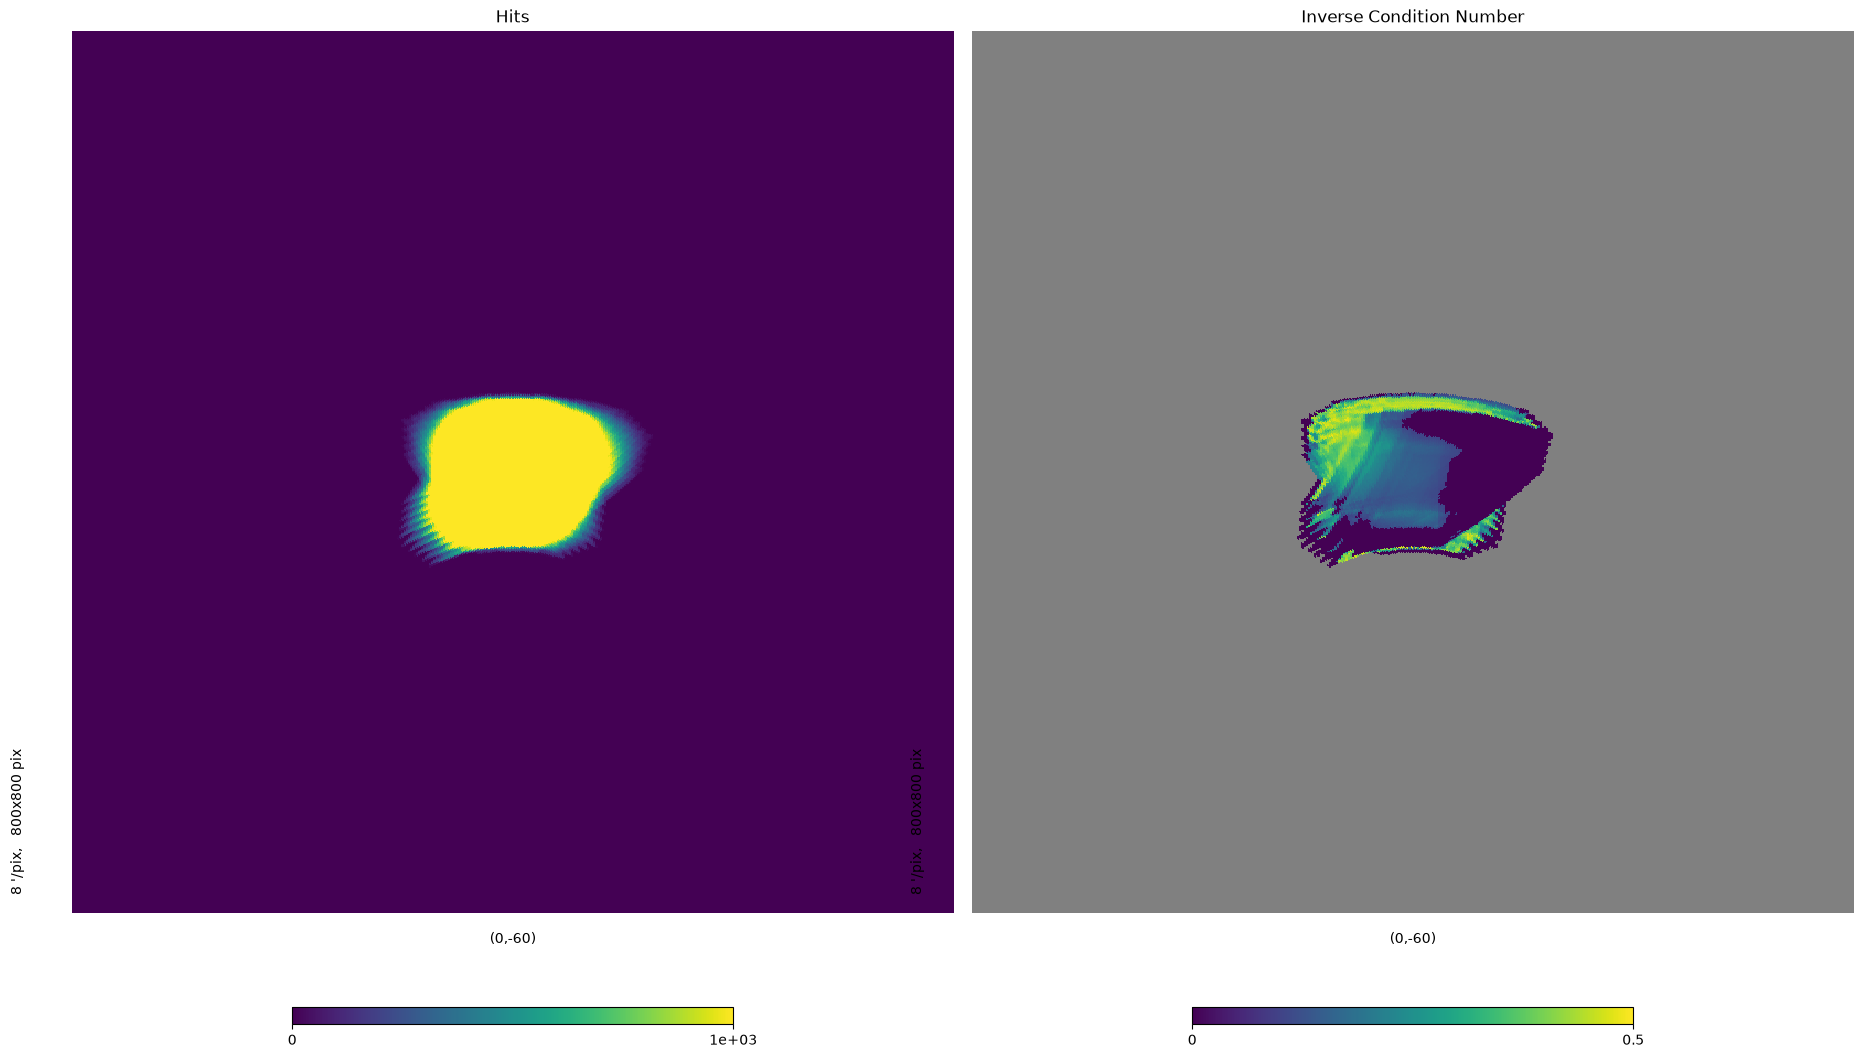

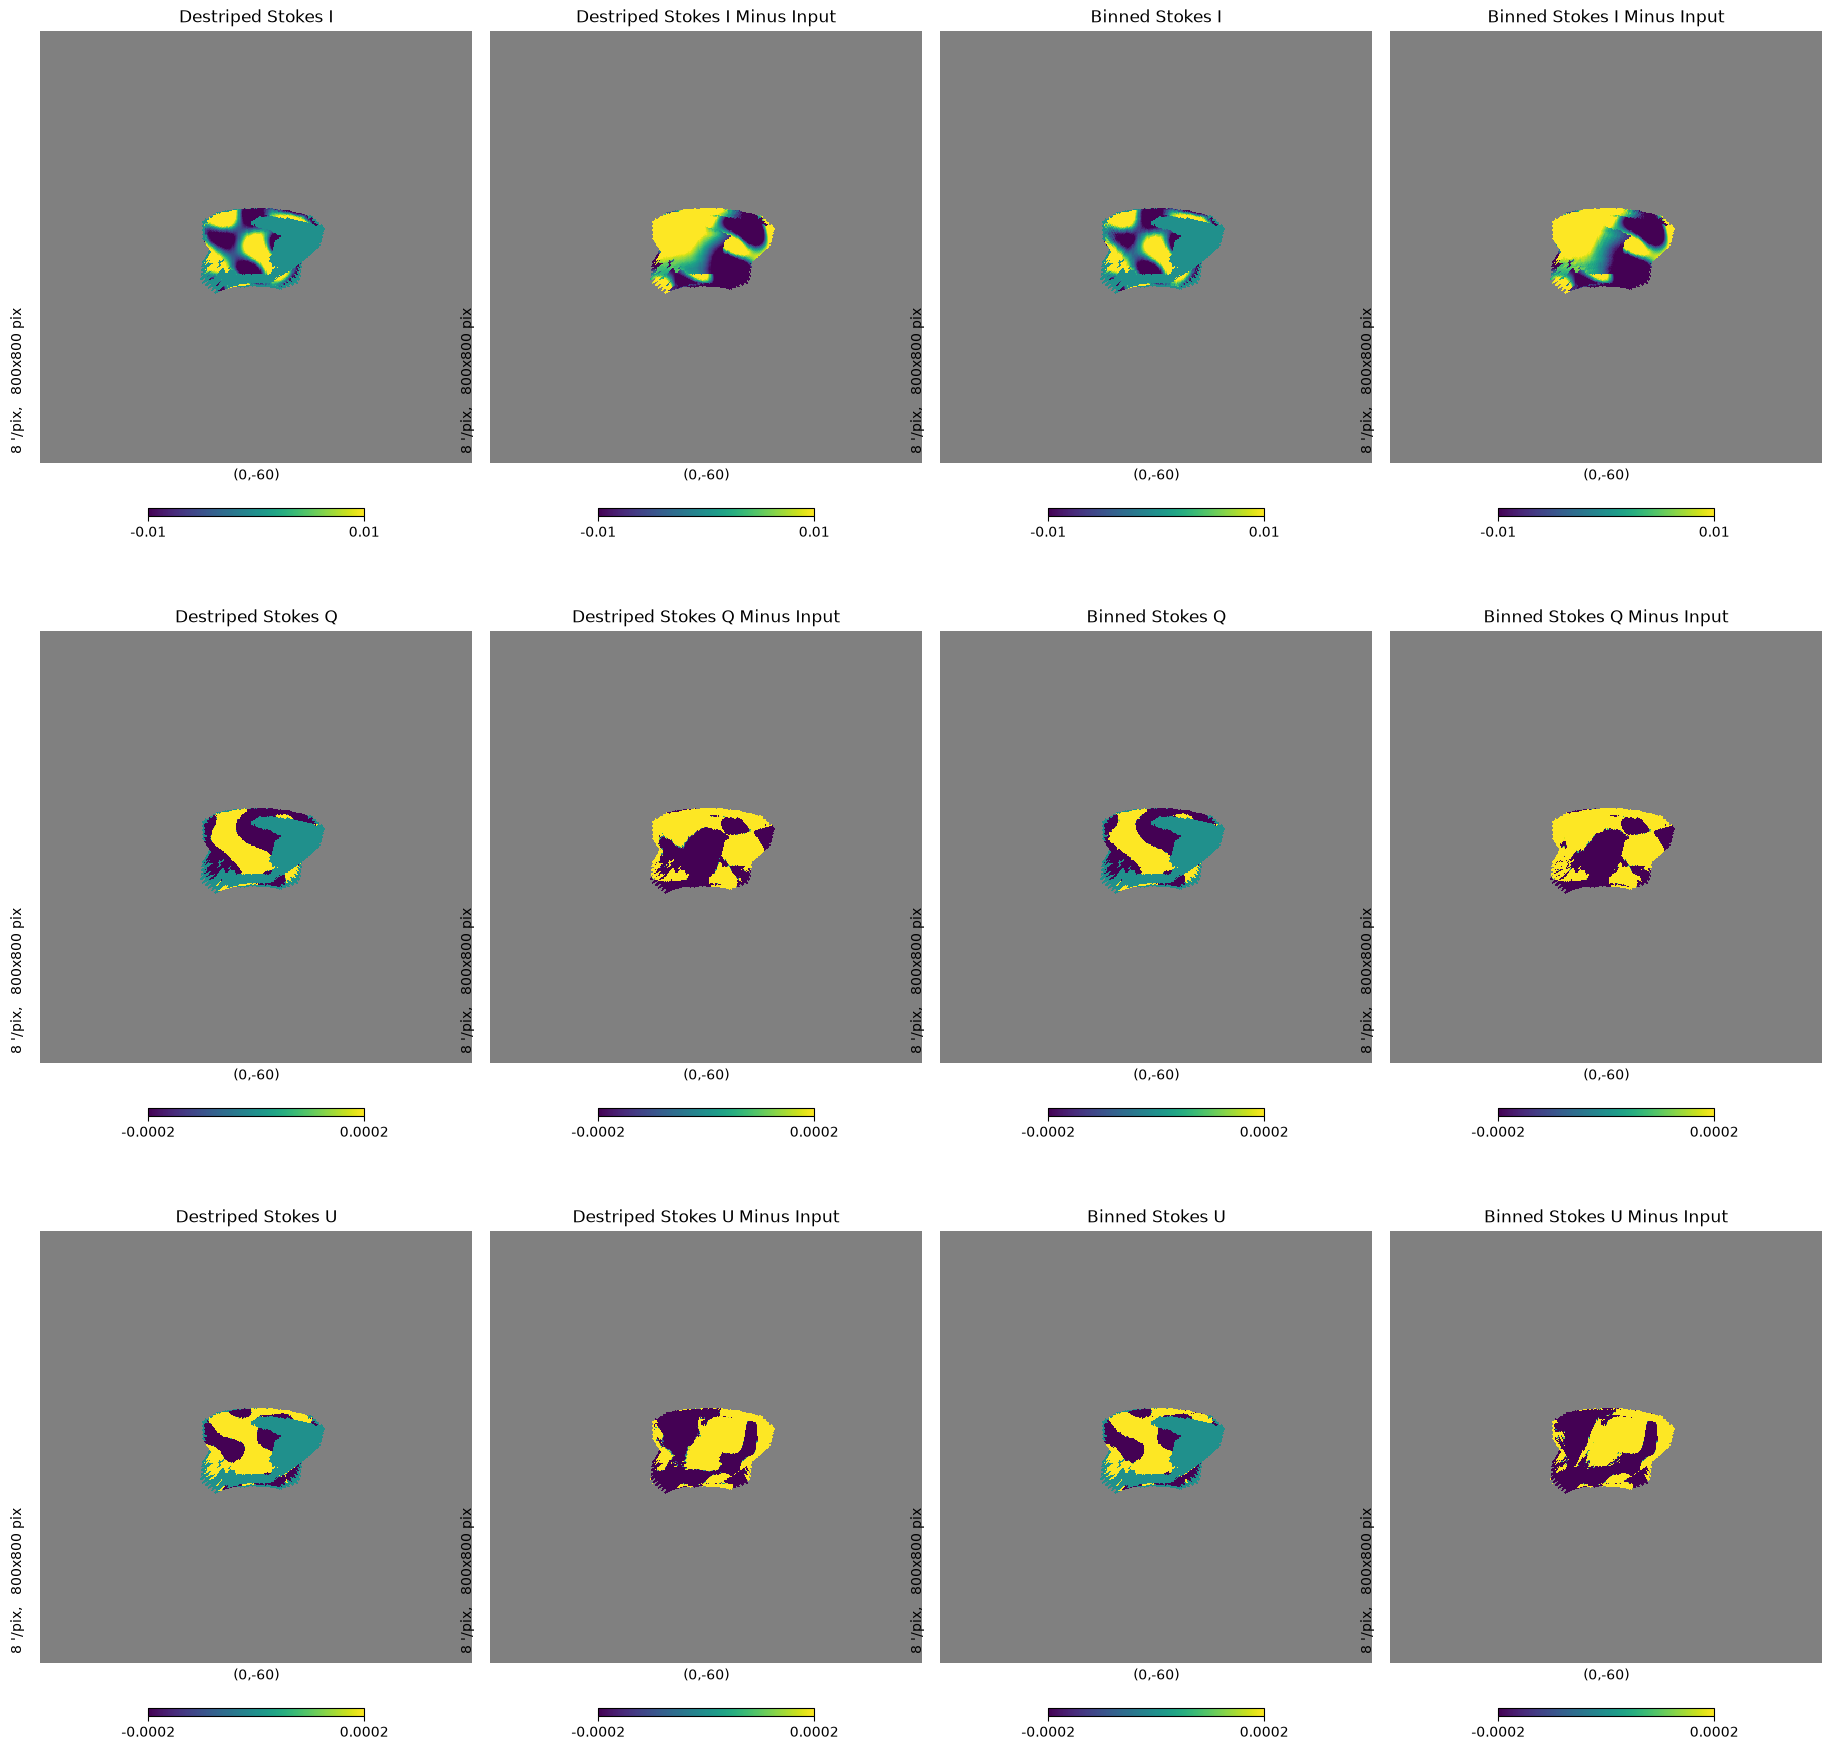

In [129]:
%matplotlib inline
plot_maps(out_root, truth=input_map_file)